# 2 — Cell typing from virtual staining

In this tutorial, we showed how to use the virtual staining results to perform cell typing.

Referenced cohort as in paper: [PatchoCell](https://huggingface.co/datasets/Kainmueller-Lab/PathoCell)

 - the cells were segmented once, by the dataset authors.
 - the reference cell types are the published labels.

## Getting the data first

Pathocell dataset is public of 36 GB. We do not ship this dataset in our data holder.
We used `reg016_B` as an example, which we reported in our paper.
So fetch it, and fetch only what you need:

```python
from questkit import cohort
cohort.fetch_pathocell(["reg016_B"])            # this notebook's case, ~350 MB
```

They land in `data/PathoCell`, or wherever `QUEST_DATA` points.

In [1]:
import _common 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from quest import QuestGenerator
from questkit import cohort, cells, celltyping, plotting 
from questkit.predict_mif import predict_region

REGION = "reg016_B"
cohort.fetch_pathocell([REGION])   # ~350 MB, no-op once it is there
PANEL = cohort.pathocell_panel()
print(f"typing panel ({len(PANEL)}):", PANEL)

[pathocell] all 1 regions already in data/PathoCell
typing panel (46): ['CD44', 'FoxP3', 'CD8', 'p53', 'GATA3', 'CD45', 'Tbet', 'bCatenin', 'HLA-DR', 'PDL1', 'Ki67', 'CD45RA', 'CD4', 'CD21', 'Vimentin', 'CD20', 'LAG3', 'CD5', 'IDO1', 'PanCK', 'CD11b', 'CD56', 'aSMA', 'BCL2', 'CD25', 'CollagenIV', 'CD11c', 'PD1', 'DAPI', 'GranzymeB', 'EGFR', 'VISTA', 'CD15', 'CD194', 'ICOS', 'CD71', 'CD3e', 'CD163', 'CD57', 'CD45RO', 'CD68', 'CD31', 'Podoplanin', 'CD34', 'CD38', 'CD138']


In [2]:
# PathoCell's own vocabulary, used as published: 15 classes, of which Background is not a cell
he8, inst, ids, _real, gt = cohort.load_pathocell_typing(REGION, classes="coarse15")
print(f"{REGION}: {he8.shape[1]}x{he8.shape[0]} px, {len(ids)} published cells")
import collections
for name, k in collections.Counter(t for t in gt if t).most_common():
    print(f"  {name:24s} {k:5d}")
print(f"  {'(background, not typed)':24s} {int(sum(t is None for t in gt)):5d}")  # The labels are PathoCell's own, used as published 15-class `gt_ct_coarse` vocabulary.

reg016_B: 1920x1440 px, 2421 published cells
  Tumor cells                664
  Granulocytes               486
  Stroma                     464
  Macrophages/Monocytes      364
  Smooth muscle              213
  Vasculature/Lymphatics     101
  T cells                     77
  Other cells                 13
  Nerves                      10
  B cells                      2
  Plasma cells                 1
  (background, not typed)     26


In [3]:
gen = QuestGenerator(_common.MODEL, device=_common.DEVICE)
virt = predict_region(gen, he8, PANEL)          # (17, H, W), patches stitched with averaged seams

# per-cell means through the published mask, then per-region p99 scaling
M_virt, _ = cells.cell_means(virt, inst)
M_virt = np.stack([cells.scale_p99(M_virt[:, i]) for i in range(M_virt.shape[1])], 1)
print("per-cell table:", M_virt.shape, "— read through the authors' own footprints")

per-cell table: (2421, 46) — read through the authors' own footprints


## The typer, and the one discipline that makes the figure honest

Cells are typed by a multinomial logistic regression on the virtual per-cell means.

**The displayed region is held out of the fit.** The shipped weights were fitted on 106 of the 109
regions, holding out the three any notebook here displays — `reg016_B` for this figure, `reg032_B`
and `reg033_B` for notebook 3. 

*N.B.* The paper does this as 5-fold out-of-fold instead, which is not the same weights as this tutorial.

To rebuild the classifier:
```
python -m questkit.fit_typer --classes coarse15
```

In [4]:
import os
T = celltyping.load_typers(os.path.join(_common.QUEST_CODE, "checkpoints",
                                        "celltyper_quest-semantic.npz"))["virtual"]
print(f"virtual typer: {T['n_train']:,} cells, {len(T['classes'])} classes "
      f"({T['scheme']}), on {len(T['panel'])} markers")
print("held out of the fit:", T["holdout"])
assert REGION in T["holdout"].split(","), \
    f"{REGION} is not held out of the typer fit; this figure would be training data"
assert T["scheme"] == "coarse15", "these weights are for a different label vocabulary"
assert T["panel"] == PANEL

labelled = np.array([t is not None for t in gt])
types_virt = np.where(labelled, celltyping.apply_typer(T, M_virt, PANEL), None)

virtual typer: 210,002 cells, 14 classes (coarse15), on 46 markers
held out of the fit: reg016_B,reg032_B,reg033_B


We showcase the same region as in our paper.

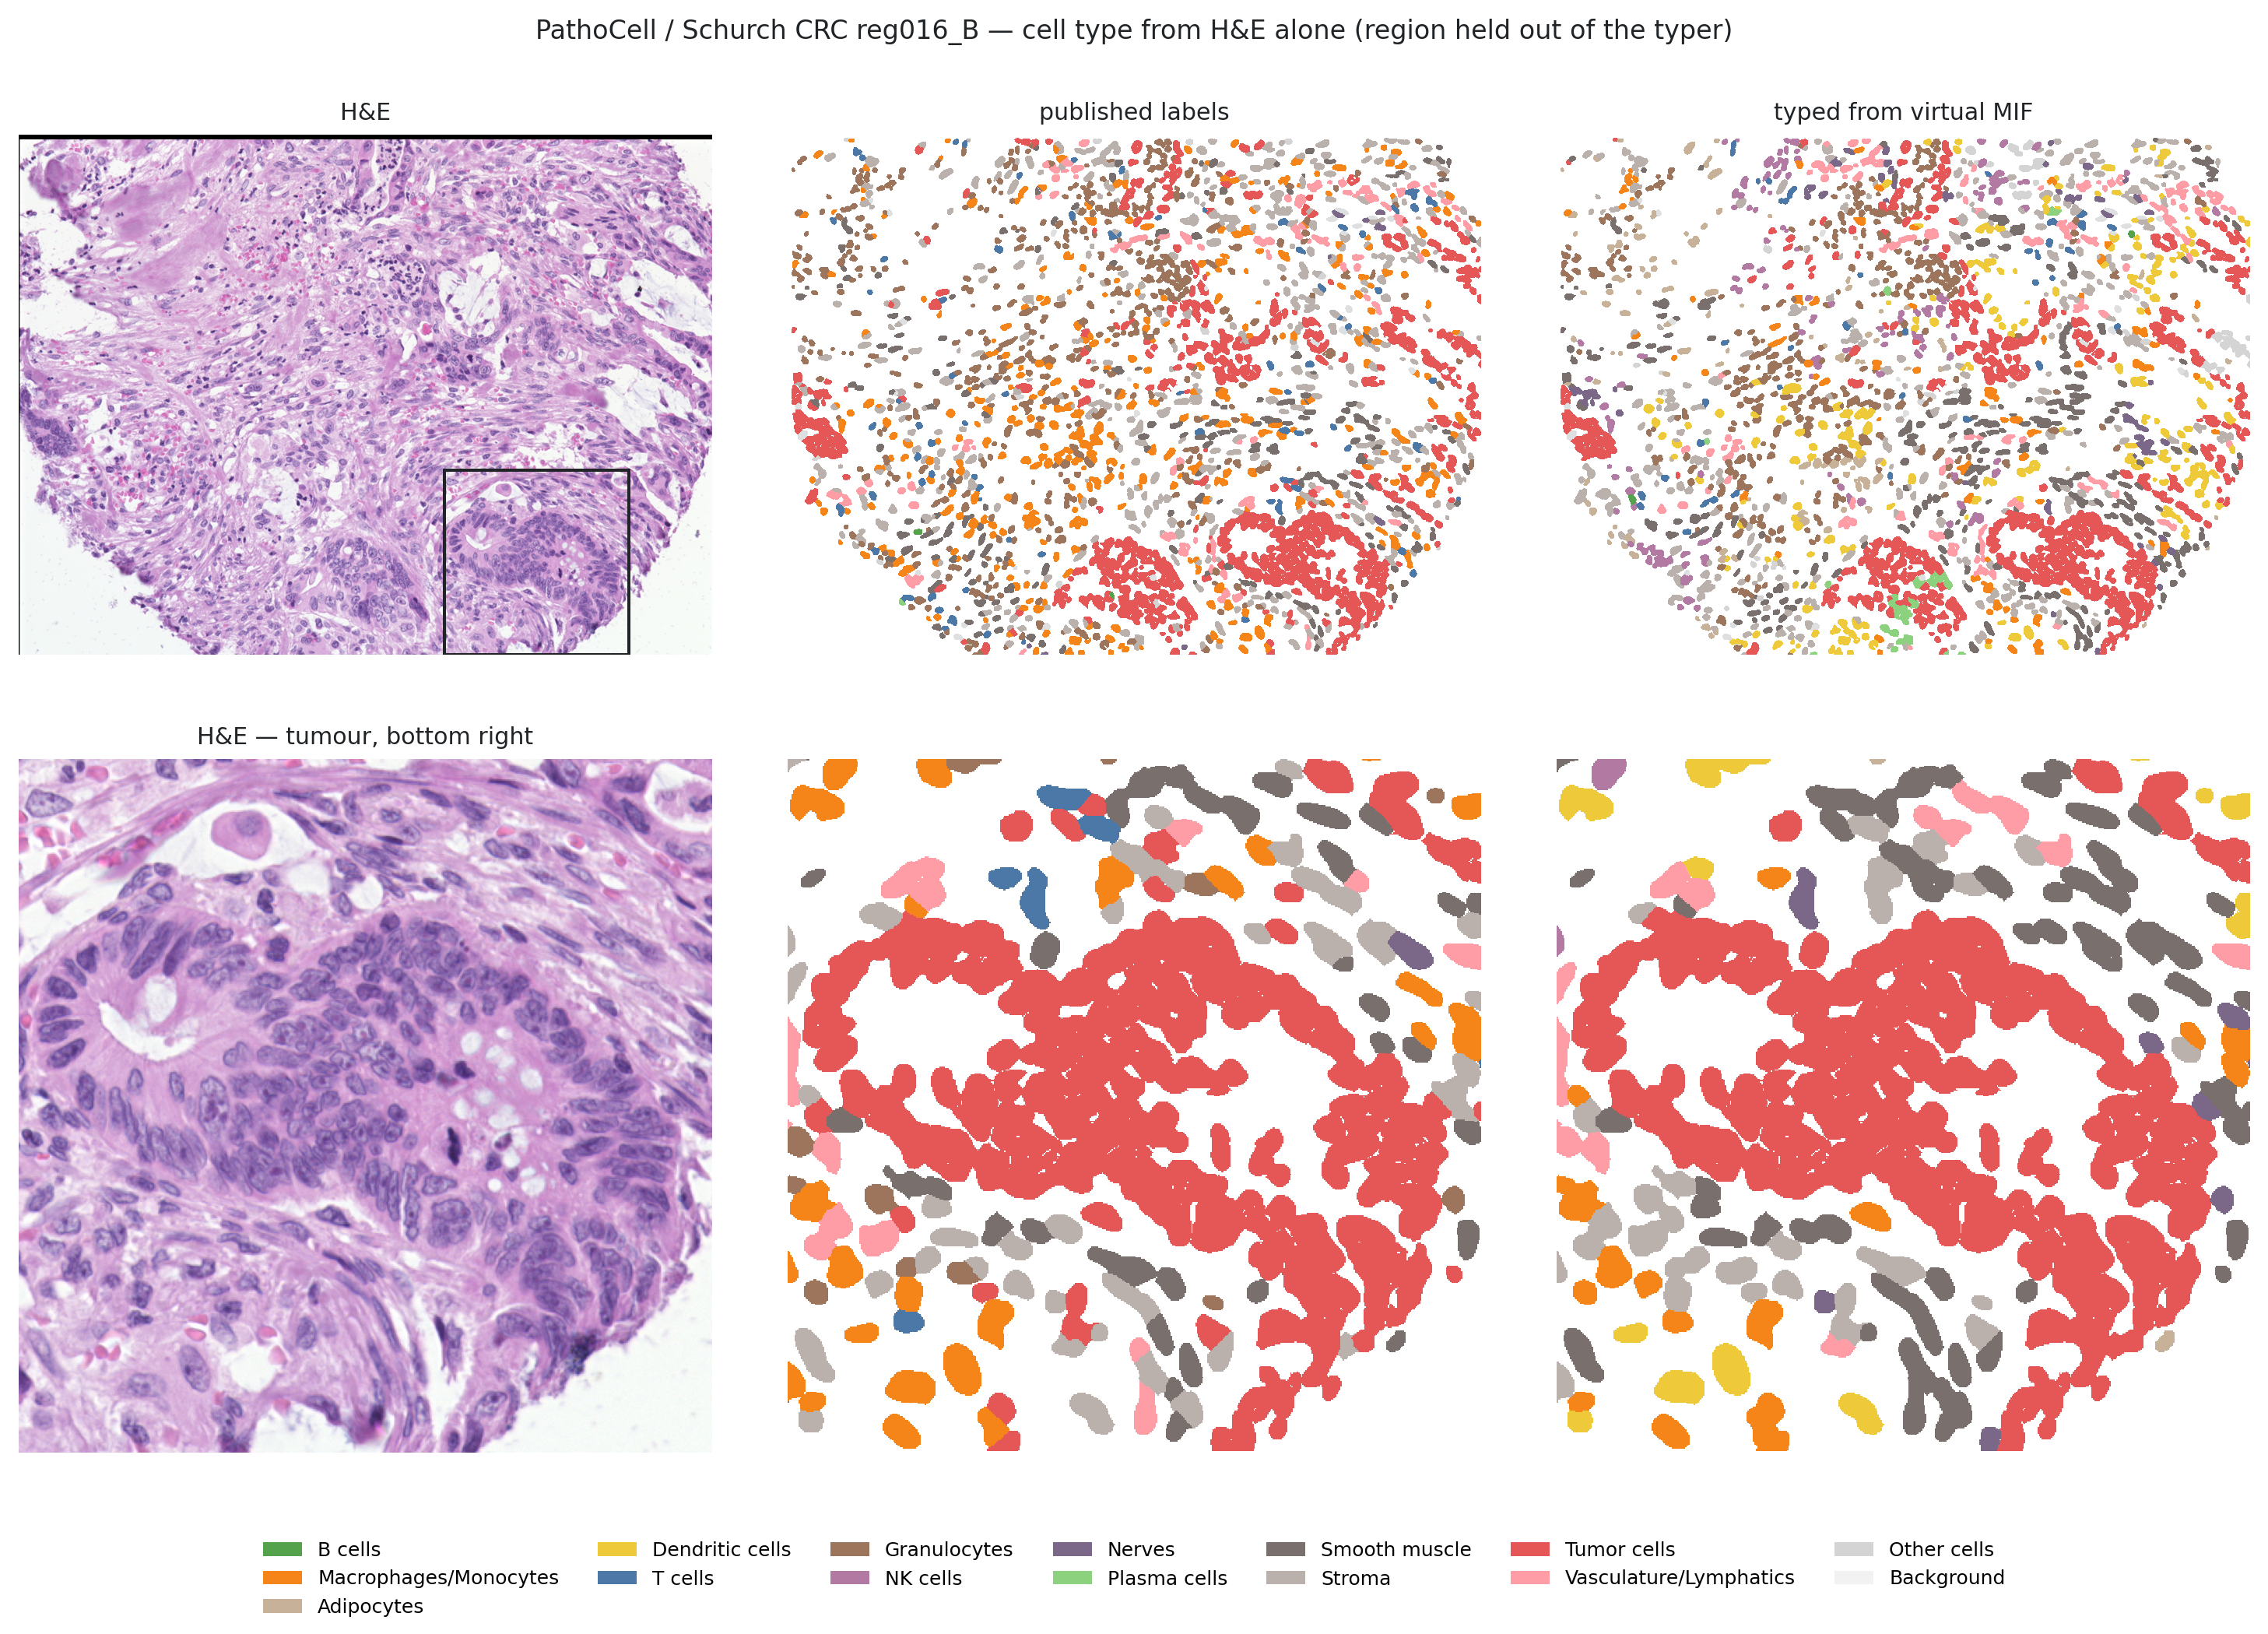

In [5]:
CROP = 512
tumour = np.array([t == "Tumor cells" for t in gt])
xs, ys = cells.centroids(inst)
br = tumour & (xs > inst.shape[1] / 2) & (ys > inst.shape[0] / 2)
x0 = int(np.clip(np.median(xs[br]) - CROP / 2, 0, inst.shape[1] - CROP))
y0 = int(np.clip(np.median(ys[br]) - CROP / 2, 0, inst.shape[0] - CROP))
box = (slice(y0, y0 + CROP), slice(x0, x0 + CROP))

arms = [(gt, "published labels"), (types_virt, "typed from virtual MIF")]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.6),
                         gridspec_kw={"height_ratios": [inst.shape[0] / inst.shape[1], 1.0]})
for r, sl in enumerate([(slice(None), slice(None)), box]):
    axes[r, 0].imshow(he8[sl])
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    for sp in axes[r, 0].spines.values():
        sp.set_visible(False)
    axes[r, 0].set_title("H&E" if r == 0 else "H&E — tumour, bottom right", fontsize=9,
                         color=plotting.INK, pad=6)
    for c, (ty, title) in enumerate(arms):
        handles = plotting.paint_types(axes[r, c + 1], inst[sl], ids, ty,
                                       title=title if r == 0 else "")
axes[0, 0].add_patch(Rectangle((x0, y0), CROP, CROP, fill=False, ec=plotting.INK, lw=1.2))
fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False, fontsize=7.5)
fig.suptitle(f"PathoCell / Schurch CRC {REGION} — cell type from H&E alone "
             f"(region held out of the typer)", fontsize=10, color=plotting.INK, y=1.0)
fig.tight_layout(rect=[0, 0.09, 1, 0.98], h_pad=6.0)
plt.show()